# Markov Random Fields

Use Markov Random Fields to solve several computer vision problems.

## Image denoising

Implement an image denoising procedure based on Markov Random Fields. Use the clique and energy definitions found in Lecture 4. As optimization strategy, you can implement Iterated Conditional Modes or other algorithm. 


Bad key text.latex.preview in file C:\Users\SOFIA\Anaconda3\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test.mplstyle, line 123 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file C:\Users\SOFIA\Anaconda3\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test.mplstyle, line 155 ('mathtext.fallback_to_cm : True  # When True, use symbols from the Computer Modern')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution

Bad key savefig.jpeg_quality in file C:\Users\SOFIA\Anaconda3\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test.mplstyle, line 418 ('savefig.jpeg_quality: 95       # when a jpeg is saved, the default quality parameter.')
You proba

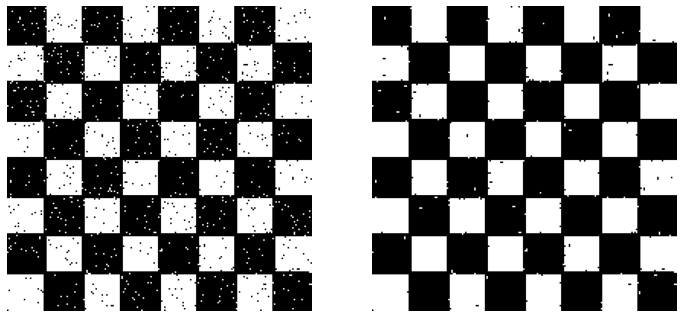

In [1]:
import warnings
warnings.filterwarnings( "ignore", module = "matplotlib\..*" )

import matplotlib.pyplot as plt


from skimage import data
from skimage.util import random_noise

import numpy as np

%matplotlib inline

plt.rcParams['figure.figsize'] = (12, 6)


def get_pixel_value(Y, i, j):
    try:
        return Y[i][j]
    except IndexError:
        return 0
    
def node_energy_denoising(X, Y, i, j, **kwargs):

    # Bias
    energy = kwargs['h'] * kwargs['y_val']
    
    # Unary term
    energy -= kwargs['nu'] * X[i][j] * kwargs['y_val'] 
    
    # Pairwise term
    energy -= kwargs['beta'] * kwargs['y_val'] * get_pixel_value(Y, i-1, j)
    energy -= kwargs['beta'] * kwargs['y_val'] * get_pixel_value(Y, i+1, j)
    energy -= kwargs['beta'] * kwargs['y_val'] * get_pixel_value(Y, i, j-1)
    energy -= kwargs['beta'] * kwargs['y_val'] * get_pixel_value(Y, i, j+1)
        
    return energy



# Note: you can use kwargs to pass optional parameters to functions
# in python. 
def optimization_algorithm(X, Y, **kwargs):
    
    m, n = np.shape(X)
    denoised = Y.copy()
    max_iter = kwargs['iterations']*m*n
    
    # optimization
    for iter in range(max_iter):
        # randomly pick a location
        i = np.random.randint(m)
        j = np.random.randint(n)
    
        ## Minimize the energy by Iterated Conditional Modes
        # compute energies for y_val = +1 and -1
        neg_energy = node_energy_denoising(X, denoised, i, j, h=kwargs['h'], beta=kwargs['beta'], nu=kwargs['nu'], y_val = -1)
        pos_energy = node_energy_denoising(X, denoised, i, j, h=kwargs['h'], beta=kwargs['beta'], nu=kwargs['nu'], y_val = 1)
        
        # assign y_val to the value with min energy
        if neg_energy < pos_energy:
            denoised[i][j] = -1
        else:
            denoised[i][j] = 1
            
    return denoised


img = data.checkerboard().astype(np.float32)
noisy = random_noise(img, 's&p', amount=0.05)
noisy[np.where(noisy==0)] = -1

X = noisy * 1
mrf = optimization_algorithm(X, noisy, iterations=5, h=1, beta=2, nu=5)

fig, ax = plt.subplots(1,2)
ax[0].imshow(noisy, cmap='binary')
ax[0].axis('off')
ax[1].imshow(mrf, cmap='binary')
ax[1].axis('off')
plt.show()


## Image segmentation

Implement a segmentation procedure to label an image as foreground and background using Markov Random Fields. Use the cliques and energies defined in Lecture 4. You can reuse the minimization algorithm implemented in the previous exercise.

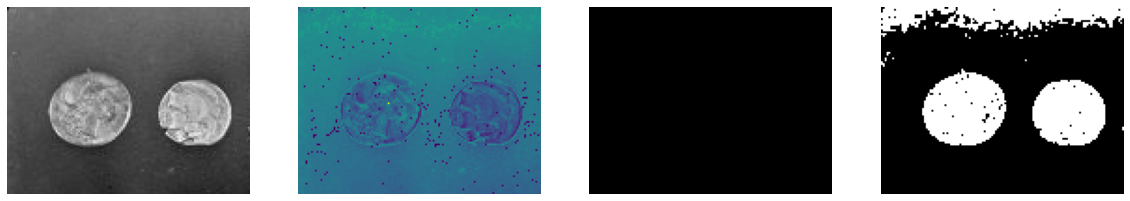

In [3]:
plt.rcParams['figure.figsize'] = (20, 6)

BG_LABEL = 100
FG_LABEL = 255

def node_energy_segmentation(X, Y, i, j, **kwargs):
    
    labels, new_val, beta, sigma = kwargs['labels'], kwargs['new_val'], kwargs['beta'], kwargs['sigma']

    # labeled
    if np.isin(labels[i,j], (BG_LABEL,FG_LABEL)):
        if labels[i,j] == new_val:
            energy = 0
        else:
            energy = 1e9
         
    # Unlabeled
    else:
        if new_val == BG_LABEL:
            energy = Y[i,j]
        else:
            energy = 255 - Y[i,j]

    # Pairwise term
    energy += beta * np.abs(X[i,j] - get_pixel_value(X, i-1, j))* \
            np.exp(-(np.square(Y[i,j] - get_pixel_value(Y, i-1, j)))/(2*sigma**2))
    
    energy += beta * np.abs(X[i,j] - get_pixel_value(X, i+1, j))* \
            np.exp(-(np.square(Y[i,j] - get_pixel_value(Y, i+1, j)))/(2*sigma**2))
                 
    energy += beta * np.abs(X[i,j] - get_pixel_value(X, i, j-1))* \
            np.exp(-(np.square(Y[i,j] - get_pixel_value(Y, i, j-1)))/(2*sigma**2))
                 
    energy += beta * np.abs(X[i,j] - get_pixel_value(Y, i, j+1))* \
            np.exp(-(np.square(Y[i,j] - get_pixel_value(X, i, j+1)))/(2*sigma**2))
    
    return energy
                 
    
def segmentation_algorithm(X, Y, **kwargs):
    
    labels, iterations, beta, sigma = kwargs['labels'], kwargs['iterations'], kwargs['beta'], kwargs['sigma']
    
    m, n = np.shape(X)
    segmented = X.copy()
    max_iter = iterations*m*n
    
    # optimization
    for iter in range(max_iter):
        # randomly pick a location
        i = np.random.randint(m)
        j = np.random.randint(n)
        
        # Foreground/ background
        fg_energy = node_energy_segmentation(segmented, Y, i, j, labels=labels, beta=beta, sigma=sigma, new_val=FG_LABEL)
        bg_energy = node_energy_segmentation(segmented, Y, i, j, labels=labels, beta=beta, sigma=sigma, new_val=BG_LABEL)
        
        # assign foreground or background to the value with min energy
        if bg_energy < fg_energy:
            segmented[i][j] = 0
            labels[i][j] = bg_energy
        else:
            segmented[i][j] = 1
            labels[i][j] = fg_energy
        
    return segmented

img = data.coins()[0:100,0:130].astype(np.float32)
X = np.zeros(img.shape)
labels = np.zeros(img.shape)
labels[40:55,40:55] = FG_LABEL
labels[20:30,10:30] = BG_LABEL


mrf = segmentation_algorithm(X, img, labels=labels, iterations=5, beta=10, sigma=2)

fig, ax = plt.subplots(1,4)
ax[0].imshow(img, cmap='gray')
ax[0].axis('off')
ax[1].imshow(labels)
ax[1].axis('off')
ax[2].imshow(X, cmap='gray')
ax[2].axis('off')
ax[3].imshow(mrf, cmap='gray')
ax[3].axis('off')
plt.show()